PART A

Student Roll No: 24BAD028
84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


/tmp/ipykernel_452/3076668381.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=os.path.dirname(dataset_path))


Dataset location: /root/.keras/datasets/aclImdb
Number of training reviews: 25000
Number of testing reviews: 25000

First 2 reviews:


,review,sentiment
0,This is the most messed up entry on IMDb that ...,0
1,Barbara Streisand directs and stars in this ve...,0



Sentiment Distribution:
sentiment
0    12500
1    12500
Name: count, dtype: int64

Sample Positive Review:
I first saw this absolutely riveting documentary in it's initial release back in 2001,and it really had a profound effect on me, so much that I bugged several of my friends to see it with me on repeat screenings. The bottom line:none of my friends walked away disappointed (ever!). This stellar film is about Scottish conceptual artist, Andy Goldsworthy,who creates some absolutely beautiful pieces of art using natural materials (wood,water,flowers,rocks,etc.)to create pieces that eventually return to their natural form (a statement in the temporary state of everything?). We get to see Goldsworthy create several works of temporary art,as well as some of his long term installations in major galleries around the world,as well as a few pieces in the natural world,as well. German film maker,Thomas Riedelsheimer directs,photographs & edits this meditation on the creative process that is 

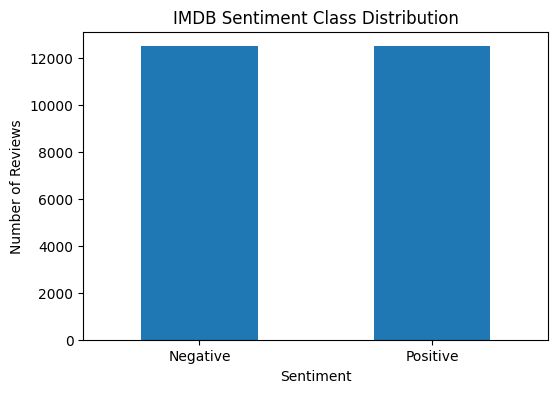

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
import os
import re
import tarfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


ROLL_NO = "24BAD028"
print("Student Roll No:", ROLL_NO)

# IMDB raw dataset URL
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

# Download dataset
dataset_path = tf.keras.utils.get_file(
    "aclImdb_v1.tar.gz",
    url,
    untar=False
)


extract_path = os.path.join(os.path.dirname(dataset_path), "aclImdb")

if not os.path.exists(extract_path):
    with tarfile.open(dataset_path, "r:gz") as tar:
        tar.extractall(path=os.path.dirname(dataset_path))

print("Dataset location:", extract_path)

# Function to load reviews
def load_reviews(split):
    texts = []
    labels = []

    for label_name, label_value in [("neg", 0), ("pos", 1)]:
        folder = os.path.join(extract_path, split, label_name)

        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                file_path = os.path.join(folder, filename)

                with open(file_path, "r", encoding="utf-8") as file:
                    texts.append(file.read())
                    labels.append(label_value)

    return texts, labels



train_texts, train_labels = load_reviews("train")
test_texts, test_labels = load_reviews("test")

print("Number of training reviews:", len(train_texts))
print("Number of testing reviews:", len(test_texts))


train_df = pd.DataFrame({
    "review": train_texts,
    "sentiment": train_labels
})

print("\nFirst 2 reviews:")
display(train_df.head(2))

# Sentiment distribution
print("\nSentiment Distribution:")
print(train_df["sentiment"].value_counts())

# Display sample positive review
print("\nSample Positive Review:")
print(train_df[train_df["sentiment"] == 1]["review"].iloc[0][:1000])

# Display sample negative review
print("\nSample Negative Review:")
print(train_df[train_df["sentiment"] == 0]["review"].iloc[0][:1000])

# Plot class distribution
train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.title("IMDB Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
# Text Preprocessing


REMOVE_STOPWORDS = False

if REMOVE_STOPWORDS:
    import nltk
    from nltk.corpus import stopwords

    nltk.download("stopwords")
    STOP_WORDS = set(stopwords.words("english"))
else:
    STOP_WORDS = set()


def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Optional stop-word removal
    if REMOVE_STOPWORDS:
        words = text.split()
        words = [word for word in words if word not in STOP_WORDS]
        text = " ".join(words)

    return text


# Apply preprocessing
train_clean = [preprocess_text(text) for text in train_texts]
test_clean = [preprocess_text(text) for text in test_texts]

# Display before and after preprocessing
print("BEFORE PREPROCESSING:")
print(train_texts[0][:800])

print("\nAFTER PREPROCESSING:")
print(train_clean[0][:800])

print("\nNumber of training reviews:", len(train_clean))
print("Number of testing reviews:", len(test_clean))

BEFORE PREPROCESSING:
This is the most messed up entry on IMDb that I've yet to stumble across. All the previous reviewers act like this is the movie. This is NOT the movie. Rather it's merely a featurette that's an extra on the DVD of the movie "The One" It also nowhere near being the 90 minutes that it's listed here as. In actuality it's barely over 13 minutes of how cool Jet Li can do martial arts. and his reflections on the movie. So yeah this IMDb entry is quite a bit fubar. Don't listen to any of the other reviews as they are ALL wrong. You can trust me, because I never feed you, dear reader, BS.<br /><br />and that's the truth. i guess u can say that i'm "the One" Reviewer that matters.

AFTER PREPROCESSING:
this is the most messed up entry on imdb that i ve yet to stumble across all the previous reviewers act like this is the movie this is not the movie rather it s merely a featurette that s an extra on the dvd of the movie the one it also nowhere near being the minutes that it

In [ ]:
# Tokenization, Numerical Sequences and Padding

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Maximum vocabulary size
MAX_WORDS = 10000

# Maximum review length
MAX_LEN = 200

# Create tokenizer
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# Build vocabulary using training reviews only
tokenizer.fit_on_texts(train_clean)

# Convert text into numerical sequences
train_sequences = tokenizer.texts_to_sequences(train_clean)
test_sequences = tokenizer.texts_to_sequences(test_clean)

# Apply padding
X_train_full = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

# Convert labels to NumPy arrays
y_train_full = np.array(train_labels)
y_test = np.array(test_labels)

# Create validation dataset from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Vocabulary size:", len(tokenizer.word_index))

print("\nX_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# Display one original review and its numerical sequence
print("\nOriginal Review:")
print(train_clean[0][:500])

print("\nNumerical Sequence:")
print(train_sequences[0][:30])

print("\nPadded Sequence:")
print(X_train[0])

# Display some vocabulary words
print("\nSample Vocabulary:")
for word, index in list(tokenizer.word_index.items())[:20]:
    print(word, "->", index)

Vocabulary size: 73268

X_train shape: (20000, 200)
X_val shape: (5000, 200)
X_test shape: (25000, 200)

y_train shape: (20000,)
y_val shape: (5000,)
y_test shape: (25000,)

Original Review:
this is the most messed up entry on imdb that i ve yet to stumble across all the previous reviewers act like this is the movie this is not the movie rather it s merely a featurette that s an extra on the dvd of the movie the one it also nowhere near being the minutes that it s listed here as in actuality it s barely over minutes of how cool jet li can do martial arts and his reflections on the movie so yeah this imdb entry is quite a bit fubar don t listen to any of the other reviews as they are

Numerical Sequence:
[11, 7, 2, 90, 4569, 56, 3161, 23, 856, 12, 10, 138, 244, 6, 7574, 627, 31, 2, 943, 1937, 498, 39, 11, 7, 2, 18, 11, 7, 24, 2]

Padded Sequence:
[  11    4   50  383    5    2  162 4693 3147   12  165 1661  219  991
    3 1071  526   10  838  197    5   96   26  444   23  342  526 5129


 PART B

In [ ]:
import tensorflow as tf

print("Student Roll No:", ROLL_NO)

# Vocabulary and embedding dimensions
VOCAB_SIZE = MAX_WORDS
EMBEDDING_DIM = 64

# Create Embedding layer
embedding_layer = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
)

print("Vocabulary Size:", VOCAB_SIZE)
print("Embedding Dimension:", EMBEDDING_DIM)

print("\nEmbedding Layer:")
print(embedding_layer)

Student Roll No: 24BAD028
Vocabulary Size: 10000
Embedding Dimension: 64

Embedding Layer:
<Embedding name=embedding, built=False>


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:

sample_sequences = X_train[:8]

# Generate embedding representations
embedded_output = embedding_layer(sample_sequences)

print("Input sequence shape:")
print(sample_sequences.shape)

print("\nEmbedding output shape:")
print(embedded_output.shape)

# Expected shape:
# (number_of_samples, sequence_length, embedding_dimension)

# Display one review's embedding
print("\nEmbedding representation of first review:")
print(embedded_output[0].numpy())

# Display first 5 words/tokens with their embedding vectors
print("\nFirst 5 token embeddings:")

for token_id in X_train[0][:5]:
    if token_id != 0:
        vector = embedding_layer(
            tf.constant([[token_id]])
        )[0, 0].numpy()

        print("Token ID:", token_id)
        print("Vector:", vector[:10], "...")
        print()

Input sequence shape:
(8, 200)

Embedding output shape:
(8, 200, 64)

Embedding representation of first review:
[[ 0.02905269  0.00324576  0.01425973 ...  0.02288909 -0.03729926
  -0.02028258]
 [-0.03979699  0.01053076  0.02231589 ... -0.03562145  0.01522995
   0.00753957]
 [-0.02219073  0.00170423 -0.00628176 ...  0.01936969  0.00427037
   0.03876719]
 ...
 [ 0.01638335  0.01185706  0.01794681 ...  0.00394833  0.00457368
  -0.02708401]
 [-0.00547489  0.03285005  0.02667719 ...  0.02983082  0.04070881
  -0.02529858]
 [-0.03979699  0.01053076  0.02231589 ... -0.03562145  0.01522995
   0.00753957]]

First 5 token embeddings:
Token ID: 11
Vector: [ 0.02905269  0.00324576  0.01425973  0.01316189  0.0357149   0.02047313
  0.03525353  0.02732897 -0.03177779 -0.0360737 ] ...

Token ID: 4
Vector: [-0.03979699  0.01053076  0.02231589 -0.01408307  0.04564531 -0.04621048
 -0.00777324  0.01251907  0.03276723 -0.02779421] ...

Token ID: 50
Vector: [-0.02219073  0.00170423 -0.00628176 -0.04117326  0

In [ ]:
# Analyze Word Embeddings


reverse_word_index = {
    index: word
    for word, index in tokenizer.word_index.items()
    if index < VOCAB_SIZE
}

# Select some common words from vocabulary
sample_words = ["good", "great", "bad", "excellent", "terrible", "movie"]

print("Word Embedding Analysis:\n")

for word in sample_words:
    word_id = tokenizer.word_index.get(word)

    if word_id is not None and word_id < VOCAB_SIZE:
        vector = embedding_layer(
            tf.constant([[word_id]])
        )[0, 0].numpy()

        print("Word:", word)
        print("Token ID:", word_id)
        print("Embedding Dimension:", len(vector))
        print("First 10 values:", np.round(vector[:10], 4))
        print()

print("Note:")
print("Each word is represented as a dense numerical vector.")
print("The embedding layer learns meaningful word representations")
print("during LSTM model training.")

Word Embedding Analysis:

Word: good
Token ID: 50
Embedding Dimension: 64
First 10 values: [-0.0222  0.0017 -0.0063 -0.0412  0.0128  0.0127  0.0412  0.0398  0.0444
  0.0174]

Word: great
Token ID: 85
Embedding Dimension: 64
First 10 values: [ 0.0437 -0.0437  0.04   -0.016   0.0063  0.0164  0.0066 -0.0296 -0.0418
 -0.0107]

Word: bad
Token ID: 76
Embedding Dimension: 64
First 10 values: [-0.0225 -0.029  -0.031  -0.0064  0.0104  0.0293 -0.0425  0.0495 -0.0311
  0.0009]

Word: excellent
Token ID: 319
Embedding Dimension: 64
First 10 values: [-0.0454  0.0386  0.043  -0.0227 -0.0224 -0.0462  0.0064  0.0071  0.0212
  0.0174]

Word: terrible
Token ID: 388
Embedding Dimension: 64
First 10 values: [-0.0034  0.0467  0.0378  0.0022  0.0172 -0.0004 -0.0408  0.0445 -0.0006
  0.0016]

Word: movie
Token ID: 18
Embedding Dimension: 64
First 10 values: [-0.0343 -0.0144 -0.0468 -0.0328  0.0421 -0.0346 -0.0447  0.0221  0.011
  0.042 ]

Note:
Each word is represented as a dense numerical vector.
The embed

PART C

In [ ]:

# Build LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

print("Student Roll No:", ROLL_NO)

# Create LSTM model
model = Sequential([

    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
        name="Embedding"
    ),

    # LSTM layer
    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2,
        name="LSTM"
    ),

    # Dropout layer
    Dropout(0.3),


    Dense(
        1,
        activation="sigmoid",
        name="Output"
    )
])

print("LSTM model created successfully.")

Student Roll No: 24BAD028
LSTM model created successfully.


In [ ]:
# Compile LSTM Model


# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

print("\nModel configuration:")
print("Optimizer         : Adam")
print("Loss Function     : Binary Crossentropy")
print("Evaluation Metric : Accuracy")

Model compiled successfully.

Model configuration:
Optimizer         : Adam
Loss Function     : Binary Crossentropy
Evaluation Metric : Accuracy


In [ ]:

# Display Model Architecture


print("LSTM MODEL SUMMARY")
print("=" * 60)

model.summary()

# Test the model with one sample
sample_output = model.predict(X_train[:1], verbose=0)

print("\nSample Input Shape:")
print(X_train[:1].shape)

print("\nSample Output Shape:")
print(sample_output.shape)

print("\nSample Sigmoid Output:")
print(sample_output)

LSTM MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Sample Input Shape:
(1, 200)

Sample Output Shape:
(1, 1)

Sample Sigmoid Output:
[[0.5022463]]


 PART D

In [ ]:
# Train LSTM Model


print("Student Roll No:", ROLL_NO)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

print("\nModel training completed.")

# Display final epoch results
print("\nFinal Training Accuracy:",
      round(history.history["accuracy"][-1], 4))

print("Final Validation Accuracy:",
      round(history.history["val_accuracy"][-1], 4))

print("Final Training Loss:",
      round(history.history["loss"][-1], 4))

print("Final Validation Loss:",
      round(history.history["val_loss"][-1], 4))

Student Roll No: 24BAD028
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 319ms/step - accuracy: 0.5375 - loss: 0.6898 - val_accuracy: 0.5164 - val_loss: 0.6893
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 303ms/step - accuracy: 0.5576 - loss: 0.6765 - val_accuracy: 0.5782 - val_loss: 0.6598
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 319ms/step - accuracy: 0.6622 - loss: 0.6127 - val_accuracy: 0.5394 - val_loss: 0.6835
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 308ms/step - accuracy: 0.7048 - loss: 0.5628 - val_accuracy: 0.7942 - val_loss: 0.4999
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 140s 303ms/step - accuracy: 0.8168 - loss: 0.4547 - val_accuracy: 0.8022 - val_loss: 0.4850

Model training completed.

Final Training Accuracy: 0.8168
Final Validation Accuracy: 0.8022
Final Training Loss: 0.4547
Final Validation Loss: 0.485


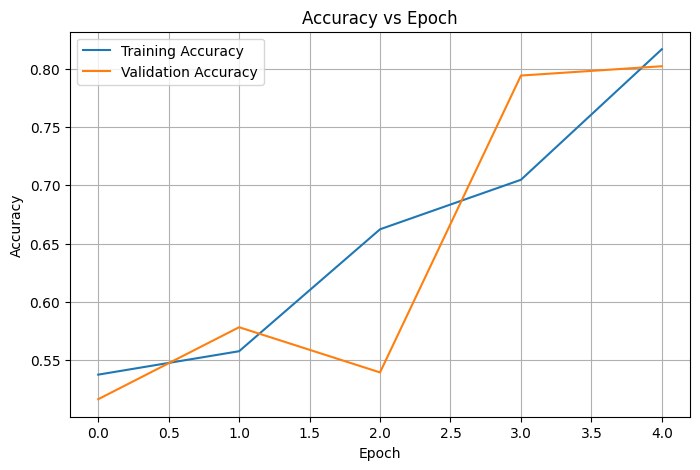

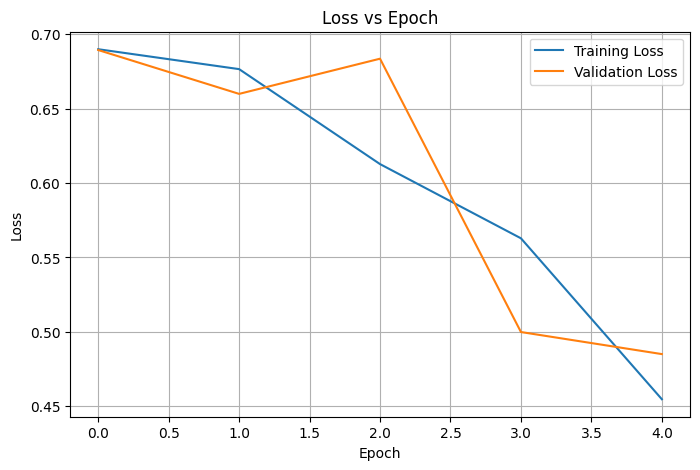

Test Loss: 0.5088
Test Accuracy: 0.7879

Evaluation Metrics
Accuracy  : 0.7879
Precision : 0.8059
Recall    : 0.7585
F1-Score  : 0.7815

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.82      0.79     12500
    Positive       0.81      0.76      0.78     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000



In [ ]:
# Training Curves and Test Evaluation


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Accuracy vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



# Loss vs Epoch
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



# Evaluate on test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))



# Predictions
y_probability = model.predict(X_test, verbose=0)

y_pred = (y_probability >= 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nEvaluation Metrics")
print("=" * 40)
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Confusion Matrix:
[[10216  2284]
 [ 3019  9481]]


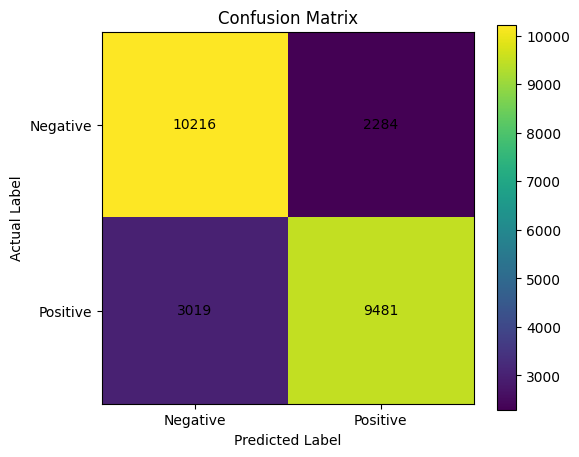

Review: This movie was absolutely fantastic and I really enjoyed it.
Predicted Probability: 0.8364
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The movie was boring, disappointing and a complete waste of time.
Predicted Probability: 0.191
Predicted Sentiment: Negative
------------------------------------------------------------
Review: Amazing acting and a wonderful story.
Predicted Probability: 0.8364
Predicted Sentiment: Positive
------------------------------------------------------------
Review: I hated this movie because it was very slow and terrible.
Predicted Probability: 0.191
Predicted Sentiment: Negative
------------------------------------------------------------

Actual vs Predicted Sentiment:


,Actual,Predicted
0,Negative,Negative
1,Negative,Negative
2,Negative,Negative
3,Negative,Negative
4,Negative,Positive
5,Negative,Negative
6,Negative,Positive
7,Negative,Negative
8,Negative,Negative
9,Negative,Negative



Model saved as IMDB_LSTM_Sentiment_Model.keras


In [ ]:
# Confusion Matrix and Sample Predictions

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

# Display values inside matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()



# Function for predicting a new review

def predict_sentiment(review):
    # Preprocess review
    cleaned_review = preprocess_text(review)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])

    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Prediction
    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("Review:", review)
    print("Predicted Probability:", round(float(probability), 4))
    print("Predicted Sentiment:", sentiment)
    print("-" * 60)



# Sample reviews

sample_reviews = [
    "This movie was absolutely fantastic and I really enjoyed it.",
    "The movie was boring, disappointing and a complete waste of time.",
    "Amazing acting and a wonderful story.",
    "I hated this movie because it was very slow and terrible."
]

for review in sample_reviews:
    predict_sentiment(review)



# Compare actual vs predicted

comparison_df = pd.DataFrame({
    "Actual": [
        "Positive" if value == 1 else "Negative"
        for value in y_test[:10]
    ],
    "Predicted": [
        "Positive" if value == 1 else "Negative"
        for value in y_pred[:10]
    ]
})

print("\nActual vs Predicted Sentiment:")
display(comparison_df)

# Optional: save trained model
model.save("IMDB_LSTM_Sentiment_Model.keras")
print("\nModel saved as IMDB_LSTM_Sentiment_Model.keras")